# [Cell 1] Data Generation & 4 CSV Export

In [1]:
# Cell 1: Data Generation & Export to 4 CSV files
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# 1. Aging Demographics & Caregiver Shortfall (2020-2040)
years = list(range(2020, 2041))
elderly_ratio = [16.0 + (i * 0.65) + np.random.uniform(-0.1, 0.1) for i in range(len(years))]
caregiver_gap = [int(15000 + (i * 2800) + np.random.randint(-500, 500)) for i in range(len(years))]

df1 = pd.DataFrame({
    'year': years,
    'elderly_population_ratio_pct': np.round(elderly_ratio, 2),
    'caregiver_shortfall_persons': caregiver_gap
})
df1.to_csv("1_demographics_caregiver_gap.csv", index=False)

# 2. Financial Fraud Loss Distribution by Age Group
age_groups = ['18-29', '30-49', '50-64', '65+']
data2 = []
for age in age_groups:
    mean_loss = 800 if age == '18-29' else (1500 if age == '30-49' else (3500 if age == '50-64' else 8500))
    for loss in np.random.exponential(scale=mean_loss, size=100):
        data2.append({'age_group': age, 'loss_amount_hkd': np.round(loss, 2)})

df2 = pd.DataFrame(data2)
df2.to_csv("2_fraud_loss_by_age.csv", index=False)

# 3. AI Companion Robot Performance Metrics
df3 = pd.DataFrame({
    'daily_interaction_min': np.round(np.random.uniform(10, 180, 200), 2),
    'cantonese_asr_accuracy_pct': np.round(np.random.uniform(75, 98, 200), 2),
    'fraud_interception_rate_pct': np.round(np.random.uniform(80, 99, 200), 2),
    'user_satisfaction_score': np.round(np.random.uniform(3.0, 5.0, 200), 2)
})
df3.to_csv("3_ai_robot_performance.csv", index=False)

# 4. Project Revenue & Cumulative ROI Trajectory (36 Months)
months = list(range(1, 37))
monthly_revenue = np.linspace(100000, 2000000, len(months)) * (1 + np.random.normal(0, 0.05, len(months)))
cum_revenue = np.cumsum(monthly_revenue)
cum_roi = ((cum_revenue - 5000000) / 5000000) * 100

df4 = pd.DataFrame({
    'month': months,
    'monthly_revenue_hkd': np.round(monthly_revenue, 2),
    'cumulative_roi_pct': np.round(cum_roi, 2)
})
df4.to_csv("4_robot_project_roi.csv", index=False)

print("All 4 Datasets successfully generated & exported to CSV!")

All 4 Datasets successfully generated & exported to CSV!


# [Cell 2] Load CSV Datasets & Setup Plotly Environment

In [2]:
# Cell 2: Load Datasets & Setup Plotly Environment
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Set default template
pio.templates.default = "plotly_white"

# Read CSV files
df1 = pd.read_csv('1_demographics_caregiver_gap.csv')
df2 = pd.read_csv('2_fraud_loss_by_age.csv')
df3 = pd.read_csv('3_ai_robot_performance.csv')
df4 = pd.read_csv('4_robot_project_roi.csv')

print("All 4 CSV Datasets loaded successfully!")

All 4 CSV Datasets loaded successfully!


# [Cell 3] Visualization 1: Demographics & Caregiver Shortfall

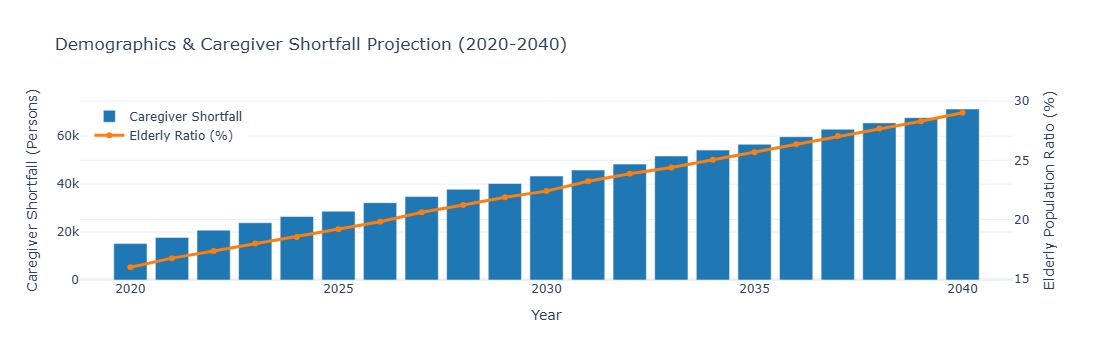

In [3]:
# Cell 3: Demographics Dual Axis Chart
fig1 = go.Figure()
fig1.add_trace(go.Bar(x=df1['year'], y=df1['caregiver_shortfall_persons'], name="Caregiver Shortfall", marker_color='#1f77b4'))
fig1.add_trace(go.Scatter(x=df1['year'], y=df1['elderly_population_ratio_pct'], name="Elderly Ratio (%)", yaxis="y2", mode='lines+markers', line=dict(color='#ff7f0e', width=3)))

fig1.update_layout(
    title="Demographics & Caregiver Shortfall Projection (2020-2040)",
    xaxis=dict(title="Year"),
    yaxis=dict(title="Caregiver Shortfall (Persons)"),
    yaxis2=dict(title="Elderly Population Ratio (%)", overlaying="y", side="right"),
    legend=dict(x=0.01, y=0.99)
)
fig1.show()

# [Cell 4] Visualization 2: Fraud Loss Distribution by Age Group

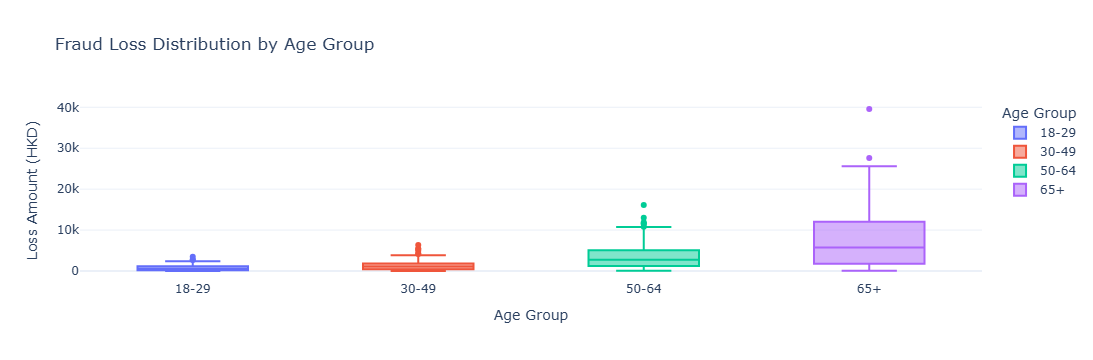

In [4]:
# Cell 4: Fraud Loss Boxplot
fig2 = px.box(df2, x='age_group', y='loss_amount_hkd', color='age_group',
              title="Fraud Loss Distribution by Age Group",
              labels={'age_group': 'Age Group', 'loss_amount_hkd': 'Loss Amount (HKD)'})
fig2.show()

# [Cell 5] AI Performance Feature Scatter Plot

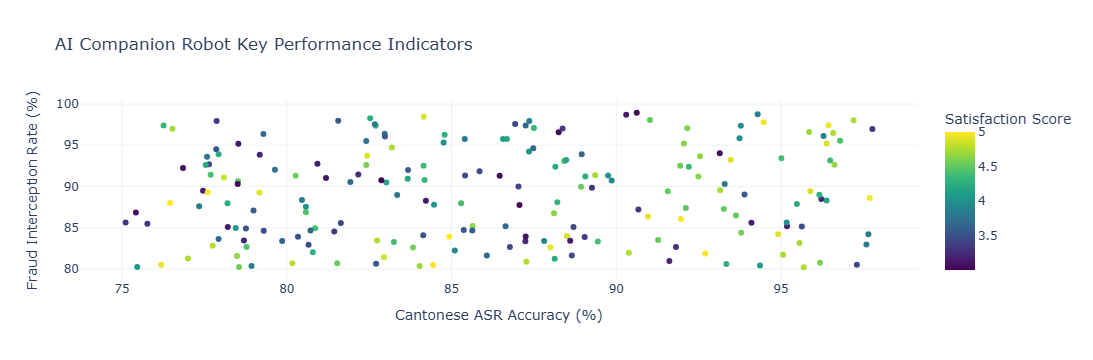

In [5]:
# Cell 5: AI Performance Scatter
fig3 = px.scatter(df3, x='cantonese_asr_accuracy_pct', y='fraud_interception_rate_pct', color='user_satisfaction_score',
                  title="AI Companion Robot Key Performance Indicators",
                  labels={'cantonese_asr_accuracy_pct': 'Cantonese ASR Accuracy (%)',
                          'fraud_interception_rate_pct': 'Fraud Interception Rate (%)',
                          'user_satisfaction_score': 'Satisfaction Score'},
                  color_continuous_scale="Viridis")
fig3.show()

# [Cell 6] Revenue & Cumulative ROI Dual Axis Trajectory

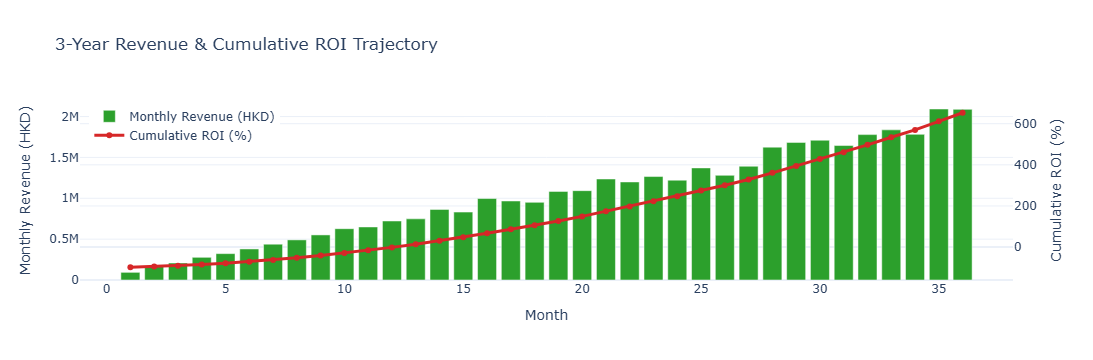

In [6]:
# Cell 6: Financial ROI Trajectory
fig4 = go.Figure()
fig4.add_trace(go.Bar(x=df4['month'], y=df4['monthly_revenue_hkd'], name="Monthly Revenue (HKD)", marker_color='#2ca02c'))
fig4.add_trace(go.Scatter(x=df4['month'], y=df4['cumulative_roi_pct'], name="Cumulative ROI (%)", yaxis="y2", mode='lines+markers', line=dict(color='#d62728', width=3)))

fig4.update_layout(
    title="3-Year Revenue & Cumulative ROI Trajectory",
    xaxis=dict(title="Month"),
    yaxis=dict(title="Monthly Revenue (HKD)"),
    yaxis2=dict(title="Cumulative ROI (%)", overlaying="y", side="right"),
    legend=dict(x=0.01, y=0.99)
)
fig4.show()

# [Cell 7] AI Performance Metrics Correlation Heatmap (Plotly Continuous Color - Plasma)

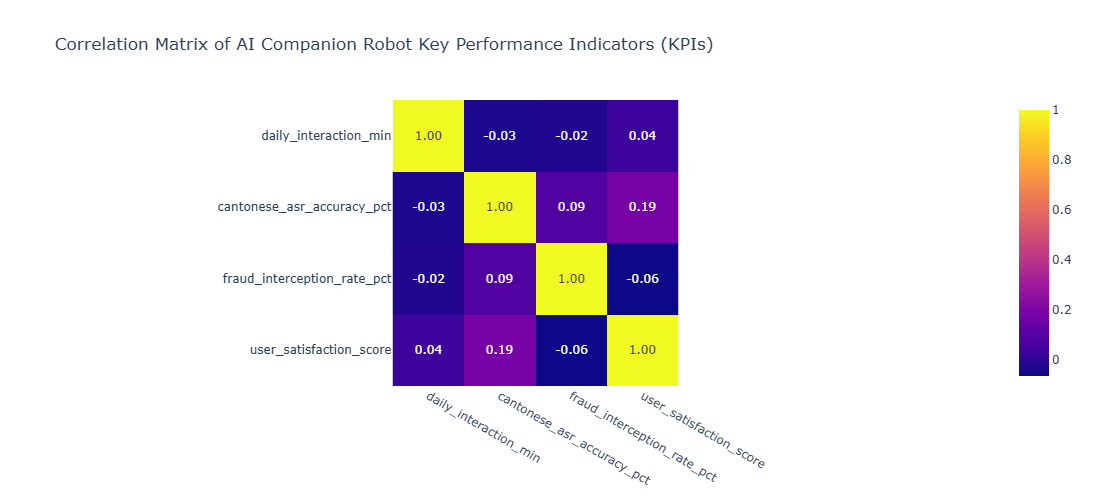

In [7]:
# Cell 7: Performance Correlation Matrix (Continuous Plasma Scale)
corr = df3[['daily_interaction_min', 'cantonese_asr_accuracy_pct', 'fraud_interception_rate_pct', 'user_satisfaction_score']].corr()

fig5 = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale='Plasma', # Continuous color
    title="Correlation Matrix of AI Companion Robot Key Performance Indicators (KPIs)"
)

fig5.update_layout(height=500, width=900)
fig5.show()

# [Cell 8] 3-Year Commercial Cumulative ROI Trajectory (Plotly Continuous Color - Turbo)

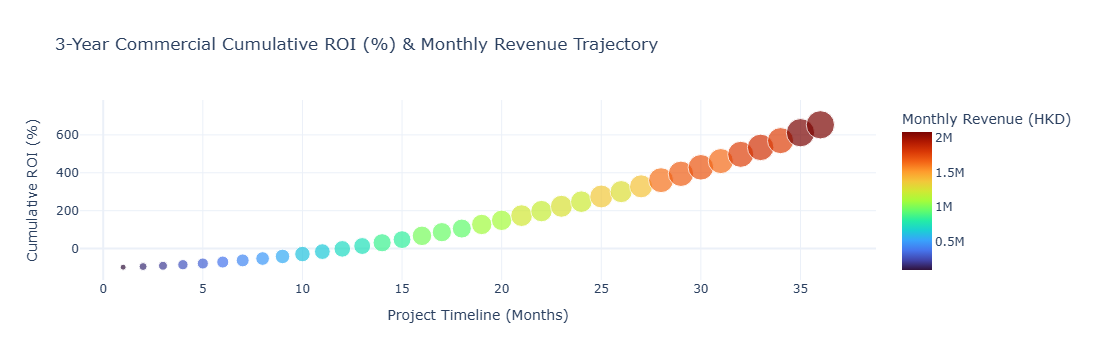

In [8]:
# Cell 8: 3-Year Cumulative Commercial ROI Trajectory (Fixed Continuous Color)
fig6 = px.scatter(
    df4,
    x='month',
    y='cumulative_roi_pct',
    color='monthly_revenue_hkd', # Continuous numerical color
    color_continuous_scale='Turbo',
    size='monthly_revenue_hkd', # Marker size scales with revenue
    title="3-Year Commercial Cumulative ROI (%) & Monthly Revenue Trajectory",
    labels={
        'month': 'Project Timeline (Months)',
        'cumulative_roi_pct': 'Cumulative ROI (%)',
        'monthly_revenue_hkd': 'Monthly Revenue (HKD)'
    }
)
fig6.show()